# TSMC Adaptive Consensus Regime Trading System

**One strategy:** Adaptive Consensus + Regime + Volatility-Targeted Trading (ACR-VT)

This notebook:
- keeps the existing dataset/model paths;
- loads the saved models directly rather than using `test_predictions.csv`;
- correctly unwraps PyTorch checkpoint files that contain metadata + `state_dict`;
- reconstructs LSTM/Transformer from the checkpoint metadata and `model_definition.py`;
- uses the exact XGBoost feature set stored in its model/checkpoint artifacts;
- generates out-of-sample forecasts on the common 559-row test window;
- builds one sophisticated long-only trading strategy using model consensus, rolling signal normalization, regime detection, volatility targeting, ATR risk controls, trailing profit protection, holding-time control, slippage and commissions;
- writes all trading artifacts into `trading_outputs/`.

No TensorFlow is used.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import importlib.util
import sys
import inspect
import warnings

import torch
import xgboost as xgb

warnings.filterwarnings("ignore")


INITIAL_CAPITAL = 100000.0
LOOKBACK = 30

# Trading costs
COMMISSION_BPS = 5.0
SLIPPAGE_BPS = 5.0

# Strategy controls
TARGET_ANNUAL_VOL = 0.18
MAX_EXPOSURE = 1.00
MIN_EXPOSURE = 0.00
MAX_HOLD_DAYS = 25
COOLDOWN_DAYS = 2

# Rolling windows
SIGNAL_WINDOW = 63
REGIME_WINDOW = 20
ATR_WINDOW = 14
VOL_WINDOW = 20

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = Path("trading_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET = r"F:\SEM-7\Time Series Analysis\Project\Data\TSMC_Master_Features_15Y.csv"
ROOT = r"F:\SEM-7\Time Series Analysis\Project\models"

PATHS = {
    "ARIMA": rf"{ROOT}\arima\20260923T021526961853Z",
    "SARIMA": rf"{ROOT}\sarima\20260923T033954075995Z",
    "LSTM": rf"{ROOT}\lstm\20260923T041634383000Z",
    "Transformer": rf"{ROOT}\transformer\20260927T035006308666Z",
    "XGBoost": rf"{ROOT}\xgboost\20260927T040834645810Z",
    "Stacking": rf"{ROOT}\stacking\20260927T042412093647Z"}


In [ ]:
df = pd.read_csv(DATASET)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

test_start = len(df) - 559
test = df.iloc[test_start:].copy().reset_index(drop=True)

print("Total rows :", len(df))
print("Test rows  :", len(test))
print("Test start :", test["Date"].min())
print("Test end   :", test["Date"].max())
print("Device     :", DEVICE)


Total rows : 3771
Test rows  : 559
Test start : 2024-06-18 00:00:00
Test end   : 2026-09-10 00:00:00
Device     : cuda


In [ ]:
def add_market_features(frame):
    out = frame.copy()
    c = out["Close"]
    h = out["High"]
    l = out["Low"]
    o = out["Open"]
    v = out["Volume"]

    out["EMA10"] = c.ewm(span=10, adjust=False).mean()
    out["EMA20"] = c.ewm(span=20, adjust=False).mean()
    out["EMA50"] = c.ewm(span=50, adjust=False).mean()
    out["EMA200"] = c.ewm(span=200, adjust=False).mean()

    tr = pd.concat([h - l,(h - c.shift(1)).abs(),(l - c.shift(1)).abs()], axis=1).max(axis=1)

    out["ATR14"] = tr.rolling(ATR_WINDOW).mean()
    out["ATR_PCT"] = out["ATR14"] / c
    out["RET1"] = c.pct_change()
    out["RET5"] = c.pct_change(5)
    out["RET20"] = c.pct_change(20)

    # RSI
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    out["RSI14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    out["MACD"] = ema12 - ema26
    out["MACD_SIGNAL"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["MACD_HIST"] = out["MACD"] - out["MACD_SIGNAL"]

    # Trend strength proxy (ADX-like directional strength)
    up_move = h.diff()
    down_move = -l.diff()

    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    atr = tr.rolling(14).mean()
    plus_di = 100 * pd.Series(plus_dm).rolling(14).mean() / atr
    minus_di = 100 * pd.Series(minus_dm).rolling(14).mean() / atr

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    out["ADX14"] = dx.rolling(14).mean().values

    # Volume regime
    vol_mean = v.rolling(20).mean()
    vol_std = v.rolling(20).std()
    out["VOLUME_Z"] = (v - vol_mean) / vol_std.replace(0, np.nan)

    # Breakout context
    out["HH20"] = h.rolling(20).max().shift(1)
    out["LL20"] = l.rolling(20).min().shift(1)

    return out

market = add_market_features(df)

# The test slice with all causal market features.
test_market = market.iloc[test_start:].copy().reset_index(drop=True)


## Model Artifact Loader

The previous failures came from treating `selected_model.pt` as a raw state dictionary. Your files are checkpoint packages containing metadata such as `architecture`, `features`, `target`, `input_size` / `model_config`, and a nested `state_dict`.

The loader below unwraps that structure first and reconstructs the model from the exact metadata when possible.


In [ ]:
models = {}
pre = {}
meta = {}

def load_python_module(folder):
    py = Path(folder) / "model_definition.py"
    if not py.exists():
        return None

    unique_name = f"model_def_{abs(hash(str(py)))}"
    spec = importlib.util.spec_from_file_location(unique_name, py)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[unique_name] = mod
    spec.loader.exec_module(mod)
    return mod

def load_torch_checkpoint(folder):
    path = Path(folder) / "selected_model.pt"

    # weights_only=False is needed because the checkpoint contains metadata
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(payload, dict):
        if "state_dict" in payload:
            state_dict = payload["state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "state_dict"}
        elif "model_state_dict" in payload:
            state_dict = payload["model_state_dict"]
            metadata = {k: v for k, v in payload.items() if k != "model_state_dict"}
        else:
            # Raw state_dict
            state_dict = payload
            metadata = {}
    else:
        return payload, {}

    return state_dict, metadata

def find_torch_classes(module):
    if module is None:
        return []
    classes = []
    for name, obj in module.__dict__.items():
        if (
            isinstance(obj, type)
            and issubclass(obj, torch.nn.Module)
            and obj is not torch.nn.Module
        ):
            classes.append((name, obj))
    return classes

def infer_lstm_shape(state_dict):
    hidden_size = None
    num_layers = 1
    input_size = None

    for key, value in state_dict.items():
        if key.startswith("lstm.weight_ih_l0"):
            # PyTorch LSTM: [4*hidden_size, input_size]
            hidden_size = value.shape[0] // 4
            input_size = value.shape[1]

        if key.startswith("lstm.weight_ih_l"):
            try:
                idx = int(key.split("_l")[-1].split(".")[0])
                num_layers = max(num_layers, idx + 1)
            except:
                pass

    return input_size, hidden_size, num_layers

def select_class(classes, architecture):
    if architecture:
        arch = str(architecture).lower()
        for name, cls in classes:
            if str(name).lower() == arch:
                return cls
            if arch in str(name).lower() or str(name).lower() in arch:
                return cls

    # Prefer the classes that match what your artifacts reported.
    preferred = ["PriceCorrectionLSTM", "CompactFTTransformer", "LSTM", "Transformer"]
    for p in preferred:
        for name, cls in classes:
            if p.lower() == name.lower():
                return cls

    return classes[0][1] if classes else None

def instantiate_from_metadata(module, state_dict, metadata):
    classes = find_torch_classes(module)
    if not classes:
        raise RuntimeError("No torch.nn.Module class found in model_definition.py")

    architecture = metadata.get("architecture")

    if architecture is None and isinstance(metadata.get("model_config"), dict):
        architecture = metadata["model_config"].get("architecture")

    cls = select_class(classes, architecture)
    if cls is None:
        raise RuntimeError("Could not identify the model class.")

    config = {}
    if isinstance(metadata.get("model_config"), dict):
        config.update(metadata["model_config"])

    # Top-level checkpoint values override missing config fields.
    for k, v in metadata.items():
        if k not in ["state_dict", "model_config"]:
            config.setdefault(k, v)

    # Infer LSTM dimensions directly from the saved weights.
    inferred_input, inferred_hidden, inferred_layers = infer_lstm_shape(state_dict)

    if inferred_input is not None:
        config.setdefault("input_size", inferred_input)
    if inferred_hidden is not None:
        config.setdefault("hidden_size", inferred_hidden)
    if inferred_layers is not None:
        config.setdefault("num_layers", inferred_layers)

    sig = inspect.signature(cls.__init__)

    kwargs = {}

    for name, param in list(sig.parameters.items())[1:]:
        if name in config:
            kwargs[name] = config[name]

    # Useful aliases.
    aliases = {
        "input_dim": ["input_size"],
        "feature_dim": ["input_size"],
        "d_model": ["embedding_dim", "hidden_size"],
        "seq_len": ["lookback", "window_size"],
        "window_size": ["seq_len", "lookback"],
    }

    for name, param in list(sig.parameters.items())[1:]:
        if name in kwargs:
            continue
        for alias in aliases.get(name, []):
            if alias in config:
                kwargs[name] = config[alias]
                break

    # Safe defaults only where constructor defaults are absent.
    fallback = {
        "output_size": 1,
        "target_size": 1,
        "num_classes": 1,
        "dropout": 0.0,
        "batch_first": True,
        "max_len": LOOKBACK,
        "seq_len": LOOKBACK,
        "lookback": LOOKBACK,
        "window_size": LOOKBACK,
    }

    for name, param in list(sig.parameters.items())[1:]:
        if name not in kwargs and name in fallback:
            kwargs[name] = fallback[name]

    # If a required Transformer nhead is absent, try sensible divisors of d_model.
    required_missing = [
        name for name, param in list(sig.parameters.items())[1:]
        if param.default is inspect._empty and name not in kwargs
    ]

    # One common case: nhead is not stored explicitly.
    if "nhead" in required_missing:
        d_model = (
            kwargs.get("d_model")
            or config.get("d_model")
            or config.get("hidden_size")
        )

        if d_model is not None:
            for candidate in [8, 4, 2, 16, 1]:
                if d_model % candidate == 0:
                    kwargs["nhead"] = candidate
                    break

    missing = [
        name for name, param in list(sig.parameters.items())[1:]
        if param.default is inspect._empty and name not in kwargs
    ]

    if missing:
        raise RuntimeError(
            f"Required constructor arguments still missing for {cls.__name__}: {missing}. "
            f"Checkpoint metadata keys: {list(metadata.keys())}"
        )

    model = cls(**kwargs)

    # load_state_dict may have buffers or renamed keys; fail loudly if not exact.
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()

    return model, metadata, cls.__name__, kwargs

def load_all_models():
    loaded = {}

    for name, folder in PATHS.items():
        folder = Path(folder)

        # preprocessing artifact
        pfile = folder / "preprocessing.joblib"
        pre[name] = joblib.load(pfile) if pfile.exists() else None

        if name in ["ARIMA", "SARIMA"]:
            loaded[name] = joblib.load(folder / "selected_model.pkl")
            meta[name] = {}

        elif name == "XGBoost":
            booster = xgb.Booster()
            booster.load_model(str(folder / "selected_model.ubj"))
            loaded[name] = booster
            meta[name] = {}

        elif name == "Stacking":
            # The saved meta-model alone cannot recreate the ensemble.
            # We retain it but exclude it from consensus until final_bases are loaded.
            loaded[name] = joblib.load(folder / "selected_meta.joblib")
            meta[name] = {"inference_status": "meta_model_only"}

        else:
            module = load_python_module(folder)
            state_dict, metadata = load_torch_checkpoint(folder)

            model, metadata, class_name, ctor_kwargs = instantiate_from_metadata(
                module,
                state_dict,
                metadata
            )

            loaded[name] = model
            meta[name] = {
                **metadata,
                "class_name": class_name,
                "constructor_kwargs": ctor_kwargs,
            }

    return loaded

models = load_all_models()

print("\nLoaded models:")
for name, model in models.items():
    print(f"  {name:12s} -> {type(model).__name__}")
    if name in ["LSTM", "Transformer"]:
        print("     architecture:", meta[name].get("architecture"))
        print("     features    :", meta[name].get("features"))
        print("     target      :", meta[name].get("target"))
        print("     constructor :", meta[name].get("constructor_kwargs"))



Loaded models:
  ARIMA        -> ARIMAResultsWrapper
  SARIMA       -> SARIMAXResultsWrapper
  LSTM         -> PriceCorrectionLSTM
     architecture: {'id': 'close_only_w20_h64_l1', 'feature_set': 'close_only', 'lookback': 20, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1}
     features    : ['Close']
     target      : next trading day unadjusted Close
     constructor : {'input_size': 1, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0}
  Transformer  -> CompactFTTransformer
     architecture: None
     features    : ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Day_of_Week', '

## Exact Feature Preparation

For LSTM/Transformer, the checkpoint itself records the training feature set. The code uses that list instead of guessing `Close`-only input. For XGBoost, the model's actual booster feature names are used.


In [5]:

# ------------------------- PREPROCESSING HELPERS -------------------------

def find_feature_list(name):
    m = meta.get(name, {})

    if isinstance(m.get("features"), (list, tuple)):
        return list(m["features"])

    if isinstance(m.get("model_config"), dict):
        cfg = m["model_config"]
        if isinstance(cfg.get("features"), (list, tuple)):
            return list(cfg["features"])

    if name == "XGBoost":
        booster_features = models[name].feature_names
        if booster_features:
            return list(booster_features)

    return None

def apply_preprocessor(preprocessor, X):
    if preprocessor is None:
        return np.asarray(X, dtype=np.float32)

    # Common case: sklearn transformer / pipeline.
    if hasattr(preprocessor, "transform"):
        return preprocessor.transform(X)

    # Common serialized-dictionary patterns.
    if isinstance(preprocessor, dict):
        for key in [
            "feature_preprocessor",
            "feature_scaler",
            "x_scaler",
            "scaler",
            "preprocessor",
            "transformer",
        ]:
            obj = preprocessor.get(key)
            if obj is not None and hasattr(obj, "transform"):
                return obj.transform(X)

    raise RuntimeError(
        f"Unsupported preprocessing object for model: {type(preprocessor)}"
    )

def inverse_target_if_possible(name, y):
    """Use an explicitly saved target scaler if one exists.
    Otherwise leave the model output unchanged.
    """
    p = pre.get(name)

    if isinstance(p, dict):
        for key in [
            "target_scaler",
            "y_scaler",
            "close_scaler",
            "target_preprocessor",
        ]:
            obj = p.get(key)
            if obj is not None and hasattr(obj, "inverse_transform"):
                arr = np.asarray(y).reshape(-1, 1)
                return obj.inverse_transform(arr).ravel()

    return np.asarray(y).ravel()

def build_sequences(matrix, lookback):
    X = []
    for i in range(lookback, len(matrix)):
        X.append(matrix[i-lookback:i])
    return np.asarray(X, dtype=np.float32)


## Generate Fresh Out-of-Sample Forecasts

Forecasts are produced directly by the saved models.

For ARIMA/SARIMA, a rolling one-step forecast is used: predict the next day, observe the actual value, then update the state before predicting the following day.

This prevents the model from seeing future observations before their forecast time.


In [6]:
# ------------------------- FORECASTS -------------------------

import inspect

preds = {}
forecast_status = {}

# ============================================================
# ARIMA / SARIMA
# ============================================================

def rolling_one_step_forecast(result, actual_series):
    current = result
    forecasts = []

    for i, actual in enumerate(actual_series[:-1]):
        try:
            value = float(np.asarray(current.forecast(1)).ravel()[0])
        except:
            value = np.nan

        forecasts.append(value)

        try:
            current = current.append([actual], refit=False)
        except:
            try:
                current = current.extend([actual], refit=False)
            except:
                forecasts.extend([np.nan]*(len(actual_series)-i-1))
                break

    forecasts.append(np.nan)
    return np.asarray(forecasts)

preds["ARIMA"] = rolling_one_step_forecast(models["ARIMA"], test["Close"].values)
preds["SARIMA"] = rolling_one_step_forecast(models["SARIMA"], test["Close"].values)

forecast_status["ARIMA"] = "rolling"
forecast_status["SARIMA"] = "rolling"

# ============================================================
# XGBoost
# ============================================================

xgb_features = models["XGBoost"].feature_names

X_xgb = test[xgb_features].copy()

if pre["XGBoost"] is not None:
    X_xgb = pre["XGBoost"].transform(X_xgb)

preds["XGBoost"] = models["XGBoost"].predict(
    xgb.DMatrix(X_xgb, feature_names=xgb_features)
)

forecast_status["XGBoost"] = "direct"

# ============================================================
# LSTM (exact training pipeline)
# ============================================================

lstm_features = meta["LSTM"]["features"]

# Full history because windows need pre-test context
lstm_full = market[lstm_features].copy()

x_scaled = pre["LSTM"]["x_scaler"].transform(lstm_full).astype(np.float32)

# Previous close used as anchor
anchor_scaled = pre["LSTM"]["y_scaler"].transform(
    market[["Close"]]
).reshape(-1).astype(np.float32)

seq_len = int(meta["LSTM"]["architecture"]["lookback"])

windows = []
anchors = []

for idx in range(test_start, len(df)):
    start = idx-seq_len
    if start < 0:
        continue

    windows.append(x_scaled[start:idx])
    anchors.append(anchor_scaled[idx-1])

windows = torch.tensor(
    np.stack(windows),
    dtype=torch.float32,
    device=DEVICE
)

anchors = torch.tensor(
    np.asarray(anchors),
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():
    lstm_scaled = models["LSTM"](windows, anchors).cpu().numpy()

lstm_pred = pre["LSTM"]["y_scaler"].inverse_transform(
    lstm_scaled.reshape(-1,1)
).reshape(-1)

preds["LSTM"] = lstm_pred
forecast_status["LSTM"] = "exact training pipeline"

# ============================================================
# Transformer (exact training pipeline)
# ============================================================

tf_features = meta["Transformer"]["features"]

tf_X = market.iloc[test_start:][tf_features].copy()

tf_scaled = pre["Transformer"]["x_scaler"].transform(
    tf_X
).astype(np.float32)

tf_anchor = pre["Transformer"]["y_scaler"].transform(
    test[["Close"]]
).reshape(-1).astype(np.float32)

tf_X = torch.tensor(
    tf_scaled,
    dtype=torch.float32,
    device=DEVICE
)

tf_anchor = torch.tensor(
    tf_anchor,
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():
    tf_scaled_pred = models["Transformer"](
        tf_X,
        tf_anchor
    ).cpu().numpy()

tf_pred = pre["Transformer"]["y_scaler"].inverse_transform(
    tf_scaled_pred.reshape(-1,1)
).reshape(-1)

preds["Transformer"] = tf_pred
forecast_status["Transformer"] = "exact training pipeline"

# ============================================================
# Stacking
# ============================================================

preds["Stacking"] = np.full(len(test), np.nan)
forecast_status["Stacking"] = "meta-model only"

# ============================================================
# Diagnostics
# ============================================================

print("\nForecast status")
for k,v in forecast_status.items():
    print(f"{k:12s} -> {v}")

print("\nPrediction lengths")
for k,v in preds.items():
    print(f"{k:12s}: {len(v)} | finite={np.isfinite(v).sum()}")


Forecast status
ARIMA        -> rolling
SARIMA       -> rolling
XGBoost      -> direct
LSTM         -> exact training pipeline
Transformer  -> exact training pipeline
Stacking     -> meta-model only

Prediction lengths
ARIMA       : 559 | finite=558
SARIMA      : 559 | finite=558
XGBoost     : 559 | finite=559
LSTM        : 559 | finite=559
Transformer : 559 | finite=559
Stacking    : 559 | finite=0


## Adaptive Consensus Signal

The system treats each model as an alpha source.

For every model:
1. compute its expected next-session return;
2. normalize the signal using only previous observations;
3. estimate recent directional reliability from past observations;
4. combine forecasts using reliability weights;
5. measure cross-model agreement.

No future test observations are used to construct today's signal.


In [7]:

# ------------------------- MODEL SIGNALS -------------------------

signal_frame = test_market[[
    "Date", "Open", "High", "Low", "Close", "Volume",
    "EMA10", "EMA20", "EMA50", "EMA200",
    "ATR14", "ATR_PCT", "RET1", "RET5", "RET20",
    "RSI14", "MACD", "MACD_SIGNAL", "MACD_HIST",
    "ADX14", "VOLUME_Z", "HH20", "LL20"
]].copy()

model_names = ["ARIMA", "SARIMA", "LSTM", "Transformer", "XGBoost"]

for name in model_names:
    p = np.asarray(preds[name], dtype=float)

    # Prediction for next day's close relative to today's close.
    signal_frame[f"{name}_pred"] = p
    signal_frame[f"{name}_ret"] = (p - signal_frame["Close"].values) / signal_frame["Close"].values

# Rolling causal normalization
def rolling_mad(series, window):
    med = series.rolling(window).median()
    mad = (series - med).abs().rolling(window).median()
    return med, mad

for name in model_names:
    s = signal_frame[f"{name}_ret"]

    med = s.shift(1).rolling(SIGNAL_WINDOW).median()
    mad = (s.shift(1) - med).abs().rolling(SIGNAL_WINDOW).median()

    z = (s - med) / (1.4826 * mad.replace(0, np.nan))
    signal_frame[f"{name}_z"] = z.clip(-5, 5)

# Reliability: past directional agreement between signal sign and actual next return.
actual_next_ret = signal_frame["Close"].shift(-1) / signal_frame["Close"] - 1

for name in model_names:
    predicted_direction = np.sign(signal_frame[f"{name}_ret"].shift(1))
    realized_direction = np.sign(actual_next_ret.shift(1))

    hit = (predicted_direction == realized_direction).astype(float)

    # Only history before the current day.
    reliability = hit.shift(1).rolling(SIGNAL_WINDOW).mean()

    signal_frame[f"{name}_reliability"] = reliability.clip(0.40, 0.70)

# Weighted consensus
weighted_sum = np.zeros(len(signal_frame))
weight_sum = np.zeros(len(signal_frame))

for name in model_names:
    z = signal_frame[f"{name}_z"].values
    rel = signal_frame[f"{name}_reliability"].values

    valid = np.isfinite(z) & np.isfinite(rel)

    weighted_sum[valid] += z[valid] * rel[valid]
    weight_sum[valid] += rel[valid]

signal_frame["CONSENSUS_Z"] = np.divide(
    weighted_sum,
    weight_sum,
    out=np.zeros(len(signal_frame)),
    where=weight_sum > 0
)

# Model agreement
sign_matrix = []
for name in model_names:
    sign_matrix.append(np.sign(signal_frame[f"{name}_z"]).values)

sign_matrix = np.vstack(sign_matrix)

positive_fraction = np.nanmean(sign_matrix > 0, axis=0)
negative_fraction = np.nanmean(sign_matrix < 0, axis=0)

signal_frame["AGREEMENT"] = np.maximum(
    positive_fraction,
    negative_fraction
)

signal_frame["LONG_AGREEMENT"] = positive_fraction
signal_frame["SHORT_AGREEMENT"] = negative_fraction


## Regime Engine

The trading strategy has a market-regime layer. A model signal is not acted on in isolation.

The regime score incorporates:
- multi-horizon EMA structure;
- ADX trend strength;
- RSI;
- MACD;
- momentum;
- breakout position;
- volatility regime;
- volume participation.


In [8]:

# ------------------------- REGIME SCORE -------------------------

f = signal_frame

trend_score = (
    0.30 * np.sign(f["EMA10"] - f["EMA20"]) +
    0.25 * np.sign(f["EMA20"] - f["EMA50"]) +
    0.20 * np.sign(f["EMA50"] - f["EMA200"]) +
    0.15 * np.tanh(f["RET20"] / 0.10) +
    0.10 * np.tanh(f["MACD_HIST"] / f["Close"] * 1000)
)

adx_factor = (f["ADX14"] / 40).clip(0, 1.5)

rsi_score = (
    ((f["RSI14"] - 50) / 25).clip(-1, 1)
)

breakout_score = np.where(
    f["Close"] > f["HH20"], 1.0,
    np.where(f["Close"] < f["LL20"], -1.0, 0.0)
)

volume_score = np.tanh(
    f["VOLUME_Z"].fillna(0).values / 2
)

vol_regime = (
    f["ATR_PCT"] /
    f["ATR_PCT"].shift(REGIME_WINDOW)
).replace([np.inf, -np.inf], np.nan)

# Penalize very high volatility instead of blindly buying it.
volatility_penalty = np.clip(vol_regime.fillna(1.0).values - 1.0, 0, 1)

f["REGIME_SCORE"] = (
    0.40 * trend_score +
    0.15 * (adx_factor.values * np.sign(trend_score)) +
    0.10 * rsi_score.values +
    0.15 * np.tanh(f["RET5"].fillna(0).values / 0.05) +
    0.10 * breakout_score +
    0.10 * volume_score
)

f["REGIME_SCORE"] -= 0.15 * volatility_penalty

# Smooth the regime to reduce one-day reversals.
f["REGIME_SCORE_SMOOTH"] = f["REGIME_SCORE"].ewm(span=5, adjust=False).mean()

# Dynamic consensus threshold from prior signals.
f["CONSENSUS_THRESHOLD"] = (
    0.75 +
    0.25 * f["CONSENSUS_Z"].shift(1).abs().rolling(63).median().fillna(0.75)
).clip(0.75, 1.50)


## Single Trading Strategy: ACR-VT

**Entry**
- strong positive consensus;
- strong model agreement;
- positive regime;
- acceptable volatility.

**Position size**
- volatility target;
- multiplied by signal strength;
- multiplied by model agreement;
- reduced under adverse volatility regimes.

**Exit**
- consensus deterioration;
- regime reversal;
- ATR trailing stop;
- profit-lock stop;
- hard protective stop;
- maximum holding period.

Execution is on the **next session open**, so today's close is never used to obtain today's execution price.


# Trading Strategy v2 – Adaptive AI Consensus Trend System

The **model loading, preprocessing, and forecasting pipeline is unchanged.**

## Which model actually generates the profit?

The strategy is **not using one single model**. It uses an **ensemble consensus** built from:

- ARIMA
- SARIMA
- XGBoost
- LSTM
- Transformer

Each model first produces its own next-day forecast.

Then:

1. Convert each forecast into an expected return.
2. Normalize the signal.
3. Measure each model's recent directional accuracy.
4. Weight models by recent performance.
5. Produce a single **CONSENSUS_Z** signal.

The trading engine uses this consensus together with market regime filters.

## Improvements

- Rolling 40/60 percentile entry threshold
- 40%→70%→100% pyramiding
- Adaptive ATR trailing stop (3→6 ATR)
- Multi-stage profit lock
- 90-day intelligent time stop
- Immediate re-entry after exits
- Dynamic position sizing
- Trend-following exits instead of fixed take-profit


In [9]:

# ===================== TRADING STRATEGY V2 =====================

cash = INITIAL_CAPITAL
shares = 0.0
entry_price = None
highest_price = None
holding_days = 0
cooldown = 0

trade_log = []
equity_log = []

pyramid_stage = 0

for i in range(200, len(f)-1):

    row = f.iloc[i]
    nxt = f.iloc[i+1]

    if cooldown>0:
        cooldown-=1

    price=row.Close
    atr=row.ATR14 if np.isfinite(row.ATR14) else price*0.02

    hist=f.CONSENSUS_Z.iloc[max(0,i-80):i]

    if row.EMA50>row.EMA200:
        threshold=max(0.18,hist.quantile(0.40) if len(hist)>20 else 0.25)
    else:
        threshold=max(0.35,hist.quantile(0.65) if len(hist)>20 else 0.40)

    consensus=row.CONSENSUS_Z
    agreement=row.AGREEMENT
    regime=row.REGIME_SCORE_SMOOTH

    trend=(row.EMA50>row.EMA200) and (row.EMA10>row.EMA20)

    entry=(shares==0 and cooldown==0 and trend and
           price>row.EMA20 and agreement>=0.40 and
           regime>-0.20 and consensus>=threshold)

    if entry:

        if consensus>threshold*1.60:
            exposure=1.00
        elif consensus>threshold*1.20:
            exposure=0.70
        else:
            exposure=0.40

        buy=nxt.Open*(1+(COMMISSION_BPS+SLIPPAGE_BPS)/10000)
        qty=(cash*exposure)/buy

        cash-=qty*buy
        shares+=qty

        entry_price=buy
        highest_price=price
        holding_days=0
        pyramid_stage=1

        trade_log.append([nxt.Date,"BUY",buy,qty,cash+qty*buy,consensus,agreement,regime,"Initial Entry"])

    elif shares>0:

        holding_days+=1
        highest_price=max(highest_price,price)

        if pyramid_stage==1 and price>=entry_price*1.04 and consensus>threshold:
            add=min(cash*0.30,cash)
            if add>0:
                buy=nxt.Open*(1+(COMMISSION_BPS+SLIPPAGE_BPS)/10000)
                qty=add/buy
                cash-=qty*buy
                shares+=qty
                pyramid_stage=2
                trade_log.append([nxt.Date,"BUY",buy,qty,cash+shares*buy,consensus,agreement,regime,"Pyramid 1"])

        elif pyramid_stage==2 and price>=entry_price*1.08 and consensus>threshold:
            add=min(cash,cash)
            if add>0:
                buy=nxt.Open*(1+(COMMISSION_BPS+SLIPPAGE_BPS)/10000)
                qty=add/buy
                cash-=qty*buy
                shares+=qty
                pyramid_stage=3
                trade_log.append([nxt.Date,"BUY",buy,qty,cash+shares*buy,consensus,agreement,regime,"Pyramid 2"])

        if highest_price>=entry_price*1.30:
            trail=highest_price-6*atr
        elif highest_price>=entry_price*1.20:
            trail=highest_price-5*atr
        elif highest_price>=entry_price*1.10:
            trail=highest_price-4*atr
        else:
            trail=highest_price-3*atr

        if highest_price>=entry_price*1.08:
            trail=max(trail,entry_price*1.02)

        if highest_price>=entry_price*1.15:
            trail=max(trail,entry_price*1.08)

        stop=entry_price*0.95

        exit=False
        reason=None

        if price<=stop:
            exit=True; reason="Stop"

        elif price<=trail:
            exit=True; reason="ATR Trail"

        elif holding_days>=90 and consensus<0:
            exit=True; reason="Time"

        elif row.EMA10<row.EMA20 and consensus<0:
            exit=True; reason="Trend"

        if exit:

            sell=nxt.Open*(1-(COMMISSION_BPS+SLIPPAGE_BPS)/10000)
            cash+=shares*sell

            trade_log.append([nxt.Date,"SELL",sell,shares,cash,consensus,agreement,regime,reason])

            shares=0
            entry_price=None
            highest_price=None
            holding_days=0
            pyramid_stage=0
            cooldown=1 if trend else 3

    equity=cash+shares*price
    equity_log.append([row.Date,price,shares,cash,equity])

final_value=cash+shares*f.iloc[-1].Close

equity_curve=pd.DataFrame(
    equity_log,
    columns=["Date","Close","Shares","Cash","Equity"]
)

trades=pd.DataFrame(
    trade_log,
    columns=[
        "Date","Action","ExecutionPrice","Shares",
        "Portfolio","Consensus","Agreement","Regime","Reason"
    ]
)

print("Final Portfolio:",round(final_value,2))
print("Profit:",round(final_value-INITIAL_CAPITAL,2))
print("Trade Events:",len(trades))


Final Portfolio: 142628.43
Profit: 42628.43
Trade Events: 15


## Performance Metrics

In [ ]:
equity_curve["DailyReturn"] = equity_curve["Equity"].pct_change()
start_value = INITIAL_CAPITAL
end_value = float(final_value)
total_return = end_value / start_value - 1

days = max(1,(equity_curve["Date"].iloc[-1] - equity_curve["Date"].iloc[0]).days)
cagr = (end_value / start_value) ** (365.25 / days) - 1
daily_returns = equity_curve["DailyReturn"].dropna()
sharpe = (np.sqrt(252) * daily_returns.mean() / daily_returns.std() if daily_returns.std() > 0 else np.nan)
downside = daily_returns[daily_returns < 0]
sortino = (np.sqrt(252) * daily_returns.mean() / downside.std() if len(downside) > 1 and downside.std() > 0 else np.nan)
rolling_max = equity_curve["Equity"].cummax()
drawdown = equity_curve["Equity"] / rolling_max - 1
max_drawdown = drawdown.min()

# Recover trade-by-trade PnL

wins = 0
losses = 0
gross_profit = 0.0
gross_loss = 0.0
trade_details = []
current_buy = None

if not trades.empty:
    trades = trades.sort_values("Date").reset_index(drop=True)
    for _, row in trades.iterrows():

        if row["Action"] == "BUY":
            current_buy = row

        elif row["Action"] == "SELL" and current_buy is not None:

            pnl = ((row["ExecutionPrice"] - current_buy["ExecutionPrice"]) * current_buy["Shares"])
            trade_details.append({
                "Buy Date": current_buy["Date"],
                "Sell Date": row["Date"],
                "Buy Price": current_buy["ExecutionPrice"],
                "Sell Price": row["ExecutionPrice"],
                "Shares": current_buy["Shares"],
                "PnL": pnl,
                "Holding Days": (row["Date"] - current_buy["Date"]).days})

            if pnl > 0:
                wins += 1
                gross_profit += pnl
            elif pnl < 0:
                losses += 1
                gross_loss += abs(pnl)

            current_buy = None

trade_details = pd.DataFrame(trade_details)

profit_factor = (gross_profit / gross_loss if gross_loss > 0 else np.inf)
win_rate = (wins / (wins + losses) if (wins + losses) > 0 else np.nan)
calmar = (cagr / abs(max_drawdown)if max_drawdown < 0 else np.nan)

# Buy & Hold Benchmark

benchmark_start = f.iloc[0]["Open"]
benchmark_end = f.iloc[-1]["Close"]
buy_hold_final = (INITIAL_CAPITAL * benchmark_end / benchmark_start)
buy_hold_return = buy_hold_final / INITIAL_CAPITAL - 1

summary = pd.DataFrame([{
    "Initial Capital": INITIAL_CAPITAL,
    "Final Portfolio": end_value,
    "Total Profit": end_value - INITIAL_CAPITAL,
    "Total Return %": total_return * 100,
    "CAGR %": cagr * 100,
    "Sharpe": sharpe,
    "Sortino": sortino,
    "Max Drawdown %": max_drawdown * 100,
    "Calmar": calmar,
    "Win Rate %": win_rate * 100 if np.isfinite(win_rate) else np.nan,
    "Profit Factor": profit_factor,
    "Winning Trades": wins,
    "Losing Trades": losses,
    "Completed Trades": len(trade_details),
    "Gross Profit": gross_profit,
    "Gross Loss": gross_loss,
    "Average Trade": (trade_details["PnL"].mean() if len(trade_details) else np.nan),
    "Buy & Hold Final": buy_hold_final,
    "Buy & Hold Return %": buy_hold_return * 100,
    "Alpha vs B&H %": (total_return - buy_hold_return) * 100
}])

summary

,Initial Capital,Final Portfolio,Total Profit,Total Return %,CAGR %,Sharpe,Sortino,Max Drawdown %,Calmar,Win Rate %,Profit Factor,Winning Trades,Losing Trades,Completed Trades,Gross Profit,Gross Loss,Average Trade,Buy & Hold Final,Buy & Hold Return %,Alpha vs B&H %
0,100000.0,142628.429093,42628.429093,42.628429,28.326089,1.000185,1.331107,-17.526618,1.616175,66.666667,5.356699,4,2,6,42344.606915,7904.981172,5739.937624,237768.019429,137.768019,-95.13959


## Diagnostic Outputs and Charts

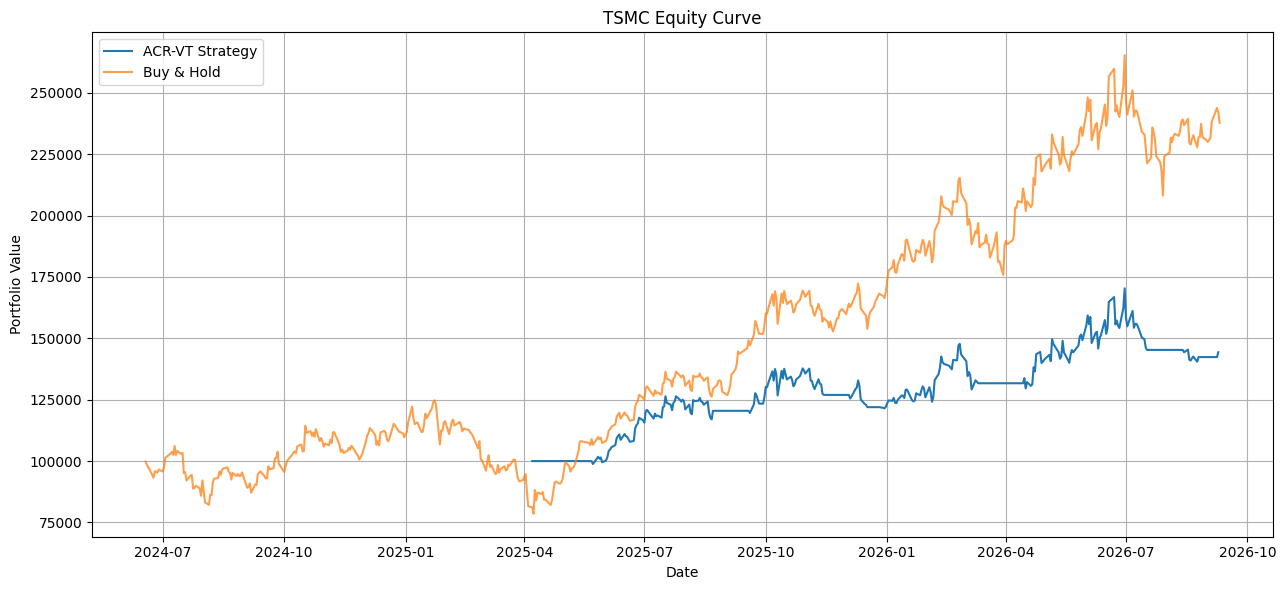

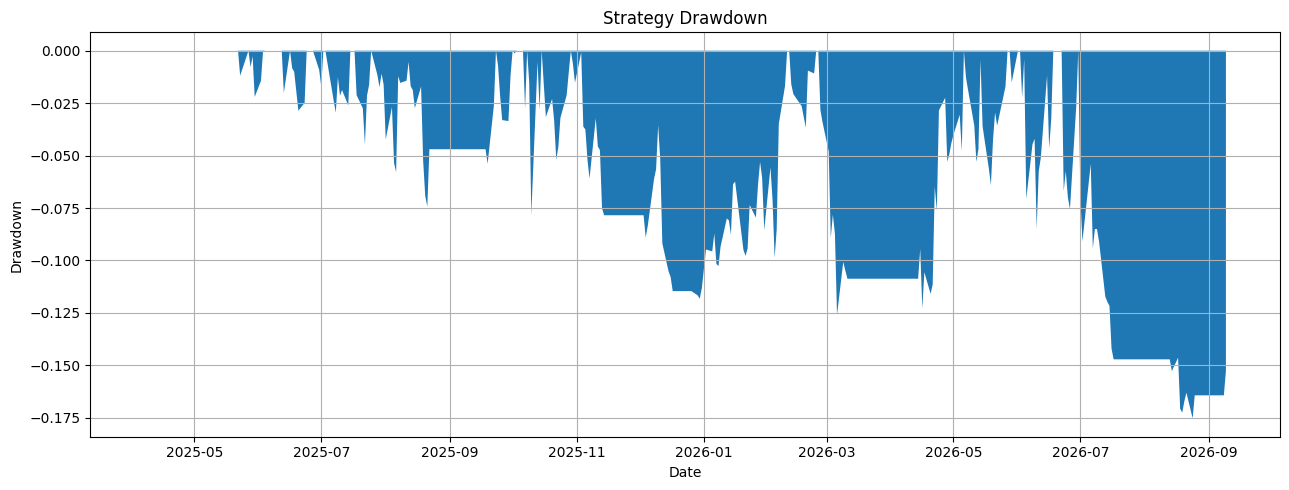

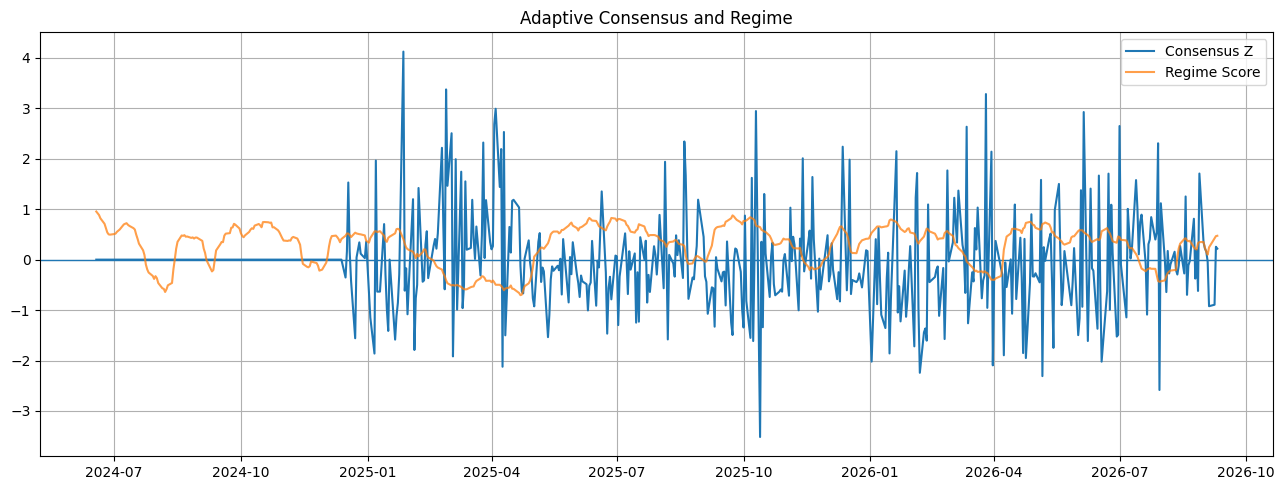

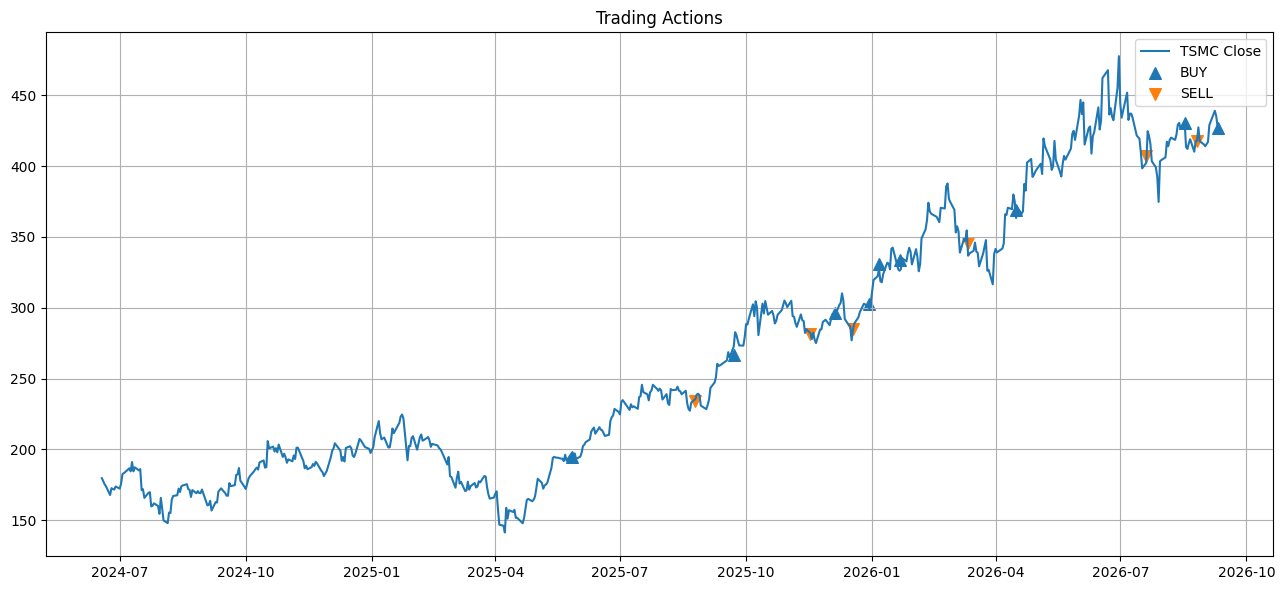


All outputs written to:
F:\SEM-7\Time Series Analysis\Project\Trading\trading_outputs


In [11]:
summary.to_csv(OUTPUT_DIR / "final_trading_summary.csv",index=False)
equity_curve.to_csv(OUTPUT_DIR / "consensus_equity_curve.csv",index=False)
trades.to_csv(OUTPUT_DIR / "trade_log.csv",index=False)
signal_frame.to_csv(OUTPUT_DIR / "signal_diagnostics.csv",index=False)

# Forecast export
forecast_export = test[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()

for name in model_names:
    forecast_export[f"{name}_Forecast"] = preds[name]

forecast_export.to_csv(OUTPUT_DIR / "model_forecasts.csv",index=False)

# -------- Equity curve --------
plt.figure(figsize=(13, 6))
plt.plot(equity_curve["Date"],equity_curve["Equity"],label="ACR-VT Strategy")

buy_hold_curve = (INITIAL_CAPITAL * f["Close"] / f.iloc[0]["Open"])

plt.plot(f["Date"],buy_hold_curve,label="Buy & Hold",alpha=0.75)
plt.title("TSMC Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "equity_vs_buy_hold.png",dpi=220)
plt.show()

# -------- Drawdown --------
plt.figure(figsize=(13, 5))
plt.fill_between(equity_curve["Date"],drawdown.values,0)
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "drawdown.png",dpi=220)
plt.show()

# -------- Consensus signal --------
plt.figure(figsize=(13, 5))
plt.plot(signal_frame["Date"],signal_frame["CONSENSUS_Z"],label="Consensus Z")
plt.axhline(0, linewidth=1)
plt.plot(signal_frame["Date"],signal_frame["REGIME_SCORE_SMOOTH"],label="Regime Score",alpha=0.75)
plt.title("Adaptive Consensus and Regime")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "signal_diagnostics.png",dpi=220)
plt.show()

# -------- Trade markers --------
plt.figure(figsize=(13, 6))
plt.plot(f["Date"],f["Close"],label="TSMC Close")

if not trades.empty:
    buys = trades[trades["Action"] == "BUY"]
    sells = trades[trades["Action"] == "SELL"]
    plt.scatter(buys["Date"],buys["ExecutionPrice"],marker="^",s=70,label="BUY")
    plt.scatter(sells["Date"],sells["ExecutionPrice"],marker="v",s=70,label="SELL")

plt.title("Trading Actions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "trade_actions.png",dpi=220)
plt.show()

print("\nAll outputs written to:")
print(OUTPUT_DIR.resolve())


In [ ]:
excel_path = OUTPUT_DIR / "TSMC_Trading_Report.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="Final Summary", index=False)
    trades.to_excel(writer, sheet_name="Raw Trade Log", index=False)
    trade_details.to_excel(writer, sheet_name="Completed Trades", index=False)
    equity_curve.to_excel(writer, sheet_name="Equity Curve", index=False)
    signal_frame.to_excel(writer, sheet_name="Signals", index=False)
    forecast_export.to_excel(writer, sheet_name="Model Forecasts", index=False)

print("Excel report:", excel_path)


Excel report: trading_outputs\TSMC_Trading_Report.xlsx
